# BBHRemnant demo

Sample BBHs with $q \in [1, 10]$, spin magnitudes $\in [0, 1]$, isotropic spin angles.
Then compute remnant mass, spin, and kick with every available model backend.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.binaries import BBHs, BBHRemnant

/Users/tousifislam/miniforge3/envs/gwgen_env/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


## Sample 5000 BBHs

In [2]:
N = 5000
rng = np.random.default_rng(42)

q = rng.uniform(1, 10, N)
M = rng.uniform(20, 200, N)
a1 = rng.uniform(0, 1, N)
a2 = rng.uniform(0, 1, N)
theta1 = np.arccos(rng.uniform(-1, 1, N))
theta2 = np.arccos(rng.uniform(-1, 1, N))
phi1 = rng.uniform(0, 2*np.pi, N)
phi2 = rng.uniform(0, 2*np.pi, N)

bbh = BBHs(M=M, q=q, a1=a1, a2=a2, theta1=theta1, theta2=theta2, phi1=phi1, phi2=phi2)
print(f'Sampled {N} BBHs')
print(f'  m1 : [{bbh.m1.min():.1f}, {bbh.m1.max():.1f}] Msun')
print(f'  m2 : [{bbh.m2.min():.1f}, {bbh.m2.max():.1f}] Msun')
print(f'  q  : [{bbh.q.min():.2f}, {bbh.q.max():.2f}]')
print(f'  a1 : [{bbh.a1.min():.3f}, {bbh.a1.max():.3f}]')
print(f'  a2 : [{bbh.a2.min():.3f}, {bbh.a2.max():.3f}]')

Sampled 5000 BBHs
  m1 : [11.0, 180.3] Msun
  m2 : [1.9, 94.9] Msun
  q  : [1.00, 10.00]
  a1 : [0.000, 1.000]
  a2 : [0.000, 1.000]


## Precessing models

| mass_spin | kick | label |
|-----------|------|-------|
| hbr (default) | gwmodel (default) | P1 |
| hbr | hlz | P2 |

In [3]:
P1 = BBHRemnant(bbh=bbh, precessing=True)
print('P1 [hbr + gwmodel]  :', P1)

P2 = BBHRemnant(bbh=bbh, precessing=True, kick_model='hlz')
print('P2 [hbr + hlz]      :', P2)

P1 [hbr + gwmodel]  : BBHRemnant(n=5000, precessing=True, mass_spin=hbr, kick=gwmodel, Mf=[19.0, 198.2], af=[0.045, 0.983], vkick=[0.4, 2651.6] km/s)
P2 [hbr + hlz]      : BBHRemnant(n=5000, precessing=True, mass_spin=hbr, kick=hlz, Mf=[19.0, 198.2], af=[0.045, 0.983], vkick=[7.6, 394.1] km/s)


## Nonprecessing models

| mass_spin | kick | label |
|-----------|------|-------|
| uib (default) | gwmodel_kick_q200 (default) | NP1 |
| uib | hlz | NP2 |
| hbr | gwmodel_kick_q200 | NP3 |
| hbr | hlz | NP4 |

In [4]:
NP1 = BBHRemnant(bbh=bbh, precessing=False)
print('NP1 [uib + q200]    :', NP1)

NP2 = BBHRemnant(bbh=bbh, precessing=False, kick_model='hlz')
print('NP2 [uib + hlz]     :', NP2)

NP3 = BBHRemnant(bbh=bbh, precessing=False, mass_spin_model='hbr')
print('NP3 [hbr + q200]    :', NP3)

NP4 = BBHRemnant(bbh=bbh, precessing=False, mass_spin_model='hbr', kick_model='hlz')
print('NP4 [hbr + hlz]     :', NP4)

NP1 [uib + q200]    : BBHRemnant(n=5000, precessing=False, mass_spin=uib, kick=gwmodel_kick_q200, Mf=[19.1, 198.1], af=[-0.442, 0.943], vkick=[4.5, 428.3] km/s)
NP2 [uib + hlz]     : BBHRemnant(n=5000, precessing=False, mass_spin=uib, kick=hlz, Mf=[19.1, 198.1], af=[-0.442, 0.943], vkick=[7.6, 394.1] km/s)
NP3 [hbr + q200]    : BBHRemnant(n=5000, precessing=False, mass_spin=hbr, kick=gwmodel_kick_q200, Mf=[19.0, 198.2], af=[0.045, 0.983], vkick=[4.5, 428.3] km/s)
NP4 [hbr + hlz]     : BBHRemnant(n=5000, precessing=False, mass_spin=hbr, kick=hlz, Mf=[19.0, 198.2], af=[0.045, 0.983], vkick=[7.6, 394.1] km/s)


## Surrogate models (surfinBH)

| mass_spin | kick | label | notes |
|-----------|------|-------|-------|
| sur7dq4remnant | sur7dq4remnant | S1 | precessing, mass+spin+kick |
| sur7dq4emri | gwmodel (default) | S2 | precessing, mass+spin only (kick from gwmodel) |
| sur3dq8remnant | sur3dq8remnant | S3 | nonprecessing (aligned-spin), mass+spin+kick |

In [5]:
S1 = BBHRemnant(bbh=bbh, precessing=True,
                mass_spin_model='sur7dq4remnant', kick_model='sur7dq4remnant')
print('S1 [sur7dq4 prec]   :', S1)

S2 = BBHRemnant(bbh=bbh, precessing=True,
                mass_spin_model='sur7dq4emri')
print('S2 [emri + gwmodel]  :', S2)

S3 = BBHRemnant(bbh=bbh, precessing=False,
                mass_spin_model='sur3dq8remnant', kick_model='sur3dq8remnant')
print('S3 [sur3dq8 nonprec] :', S3)

Loaded NRSur7dq4Remnant fit.


S1 [sur7dq4 prec]   : BBHRemnant(n=5000, precessing=True, mass_spin=sur7dq4remnant, kick=sur7dq4remnant, Mf=[19.1, 197.9], af=[0.032, 0.958], vkick=[29.1, 2928.5] km/s)
Loaded NRSur7dq4EmriRemnant fit.


S2 [emri + gwmodel]  : BBHRemnant(n=5000, precessing=True, mass_spin=sur7dq4emri, kick=gwmodel, Mf=[19.1, 197.8], af=[0.042, 0.988], vkick=[0.7, 2560.5] km/s)
Loaded NRSur3dq8Remnant fit.


S3 [sur3dq8 nonprec] : BBHRemnant(n=5000, precessing=False, mass_spin=sur3dq8remnant, kick=sur3dq8remnant, Mf=[19.1, 198.1], af=[0.001, 0.946], vkick=[1.7, 402.6] km/s)


## Surrogate: mass/spin/kick distributions

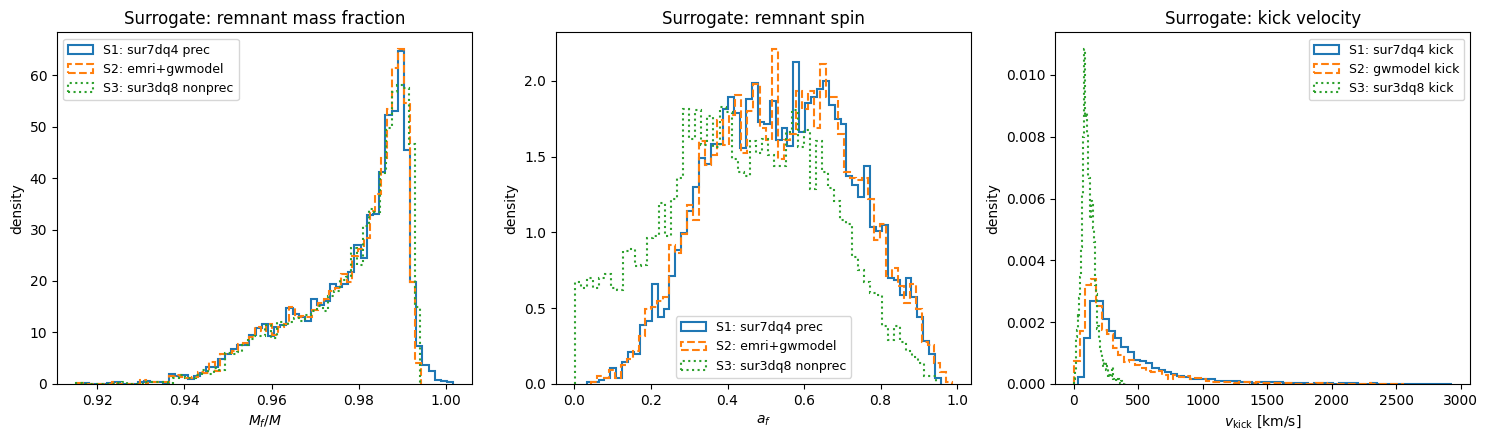

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
kw = dict(bins=60, histtype='step', lw=1.5, density=True)

ax = axes[0]
ax.hist(S1.Mf / bbh.M, label='S1: sur7dq4 prec', **kw)
ax.hist(S2.Mf / bbh.M, label='S2: emri+gwmodel', ls='--', **kw)
ax.hist(S3.Mf / bbh.M, label='S3: sur3dq8 nonprec', ls=':', **kw)
ax.set_xlabel('$M_f / M$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Surrogate: remnant mass fraction')

ax = axes[1]
ax.hist(S1.af, label='S1: sur7dq4 prec', **kw)
ax.hist(S2.af, label='S2: emri+gwmodel', ls='--', **kw)
ax.hist(S3.af, label='S3: sur3dq8 nonprec', ls=':', **kw)
ax.set_xlabel('$a_f$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Surrogate: remnant spin')

ax = axes[2]
ax.hist(S1.vkick, label='S1: sur7dq4 kick', **kw)
ax.hist(S2.vkick, label='S2: gwmodel kick', ls='--', **kw)
ax.hist(S3.vkick, label='S3: sur3dq8 kick', ls=':', **kw)
ax.set_xlabel('$v_{\\rm kick}$ [km/s]')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Surrogate: kick velocity')

fig.tight_layout()
plt.show()

## Formula vs surrogate: scatter comparison

**Precessing**: HBR (P1) vs NRSur7dq4Remnant (S1) — mass, spin, kick

**Nonprecessing**: UIB (NP1) vs NRSur3dq8Remnant (S3) — mass, spin, kick

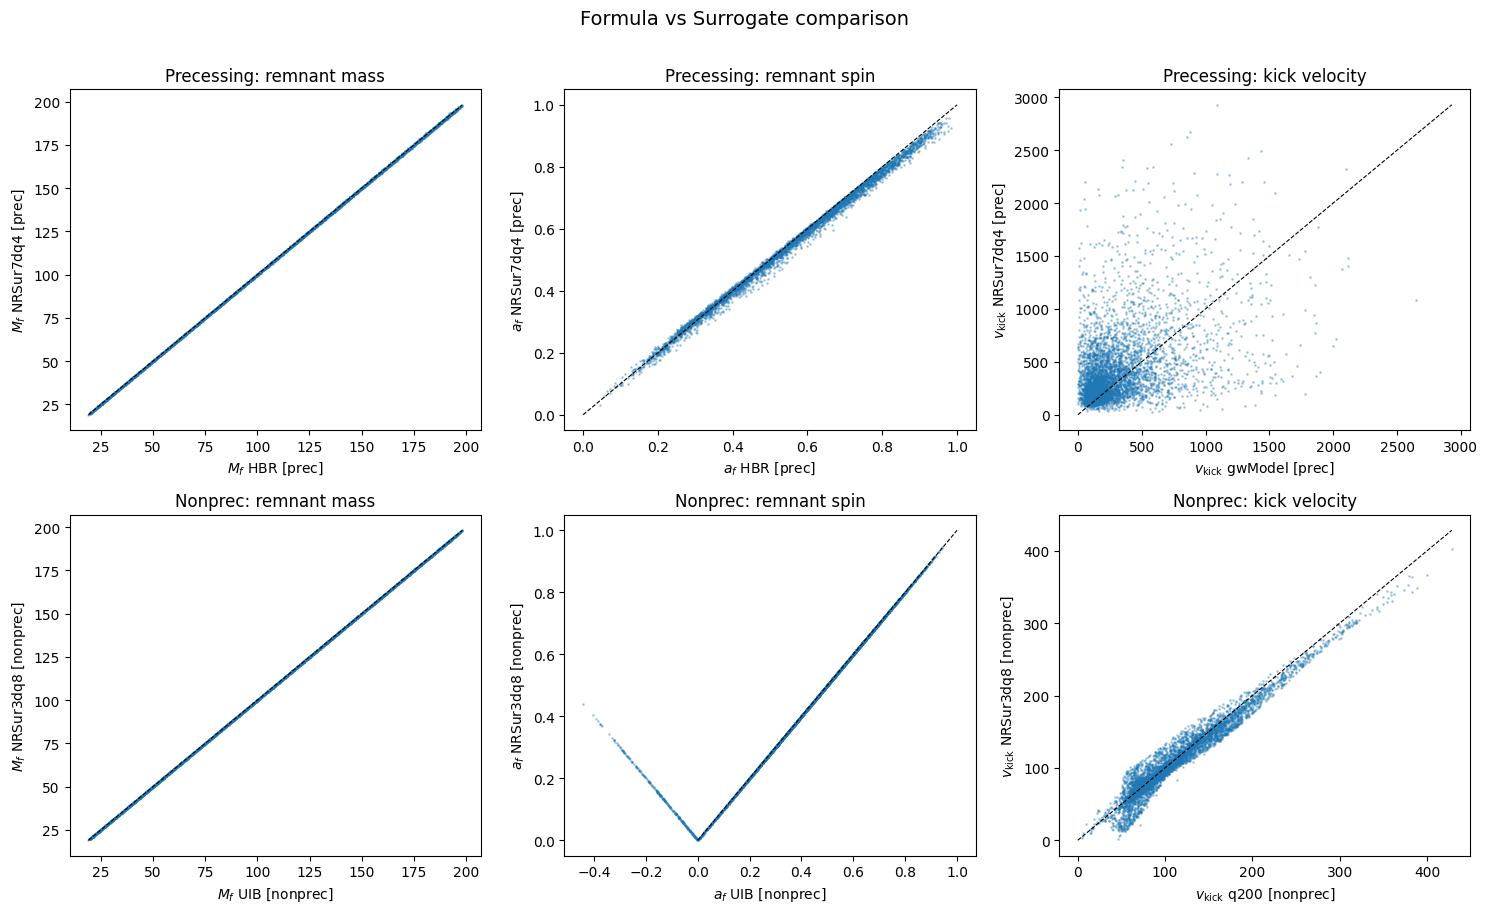

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

ax = axes[0, 0]
ax.scatter(P1.Mf, S1.Mf, s=1, alpha=0.3)
lims = [min(P1.Mf.min(), S1.Mf.min()), max(P1.Mf.max(), S1.Mf.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$M_f$ HBR [prec]')
ax.set_ylabel('$M_f$ NRSur7dq4 [prec]')
ax.set_title('Precessing: remnant mass')

ax = axes[0, 1]
ax.scatter(P1.af, S1.af, s=1, alpha=0.3)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('$a_f$ HBR [prec]')
ax.set_ylabel('$a_f$ NRSur7dq4 [prec]')
ax.set_title('Precessing: remnant spin')

ax = axes[0, 2]
ax.scatter(P1.vkick, S1.vkick, s=1, alpha=0.3)
lims = [0, max(P1.vkick.max(), S1.vkick.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$v_{\\rm kick}$ gwModel [prec]')
ax.set_ylabel('$v_{\\rm kick}$ NRSur7dq4 [prec]')
ax.set_title('Precessing: kick velocity')

ax = axes[1, 0]
ax.scatter(NP1.Mf, S3.Mf, s=1, alpha=0.3)
lims = [min(NP1.Mf.min(), S3.Mf.min()), max(NP1.Mf.max(), S3.Mf.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$M_f$ UIB [nonprec]')
ax.set_ylabel('$M_f$ NRSur3dq8 [nonprec]')
ax.set_title('Nonprec: remnant mass')

ax = axes[1, 1]
ax.scatter(NP1.af, S3.af, s=1, alpha=0.3)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('$a_f$ UIB [nonprec]')
ax.set_ylabel('$a_f$ NRSur3dq8 [nonprec]')
ax.set_title('Nonprec: remnant spin')

ax = axes[1, 2]
ax.scatter(NP1.vkick, S3.vkick, s=1, alpha=0.3)
lims = [0, max(NP1.vkick.max(), S3.vkick.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$v_{\\rm kick}$ q200 [nonprec]')
ax.set_ylabel('$v_{\\rm kick}$ NRSur3dq8 [nonprec]')
ax.set_title('Nonprec: kick velocity')

fig.suptitle('Formula vs Surrogate comparison', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Precessing: mass/spin distributions

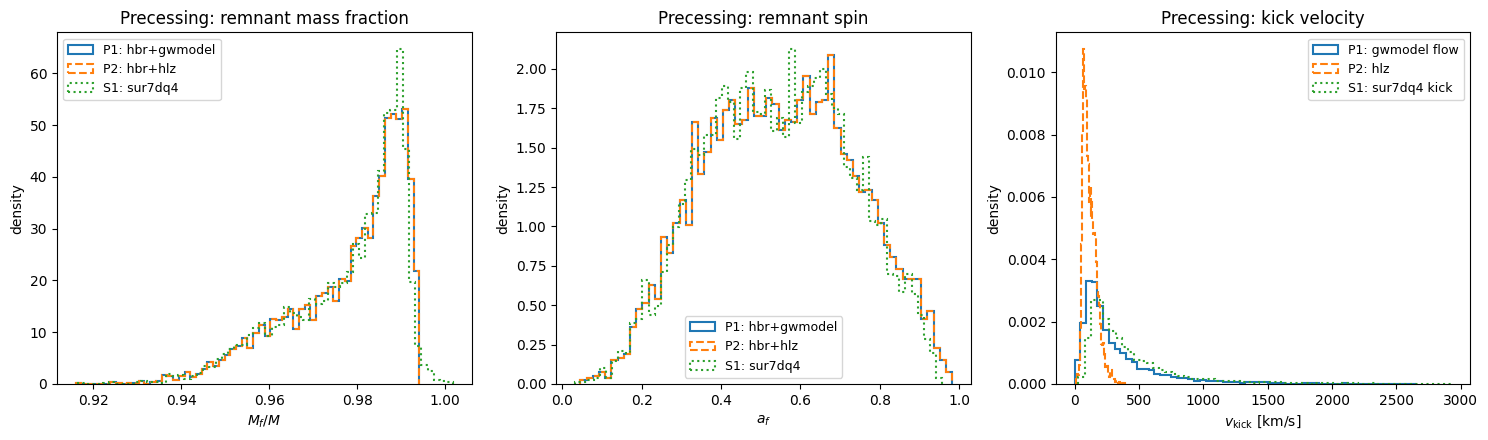

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
kw = dict(bins=60, histtype='step', lw=1.5, density=True)

ax = axes[0]
ax.hist(P1.Mf / bbh.M, label='P1: hbr+gwmodel', **kw)
ax.hist(P2.Mf / bbh.M, label='P2: hbr+hlz', ls='--', **kw)
ax.hist(S1.Mf / bbh.M, label='S1: sur7dq4', ls=':', **kw)
ax.set_xlabel('$M_f / M$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Precessing: remnant mass fraction')

ax = axes[1]
ax.hist(P1.af, label='P1: hbr+gwmodel', **kw)
ax.hist(P2.af, label='P2: hbr+hlz', ls='--', **kw)
ax.hist(S1.af, label='S1: sur7dq4', ls=':', **kw)
ax.set_xlabel('$a_f$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Precessing: remnant spin')

ax = axes[2]
ax.hist(P1.vkick, label='P1: gwmodel flow', **kw)
ax.hist(P2.vkick, label='P2: hlz', ls='--', **kw)
ax.hist(S1.vkick, label='S1: sur7dq4 kick', ls=':', **kw)
ax.set_xlabel('$v_{\\rm kick}$ [km/s]')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Precessing: kick velocity')

fig.tight_layout()
plt.show()

## Nonprecessing: mass/spin model comparison

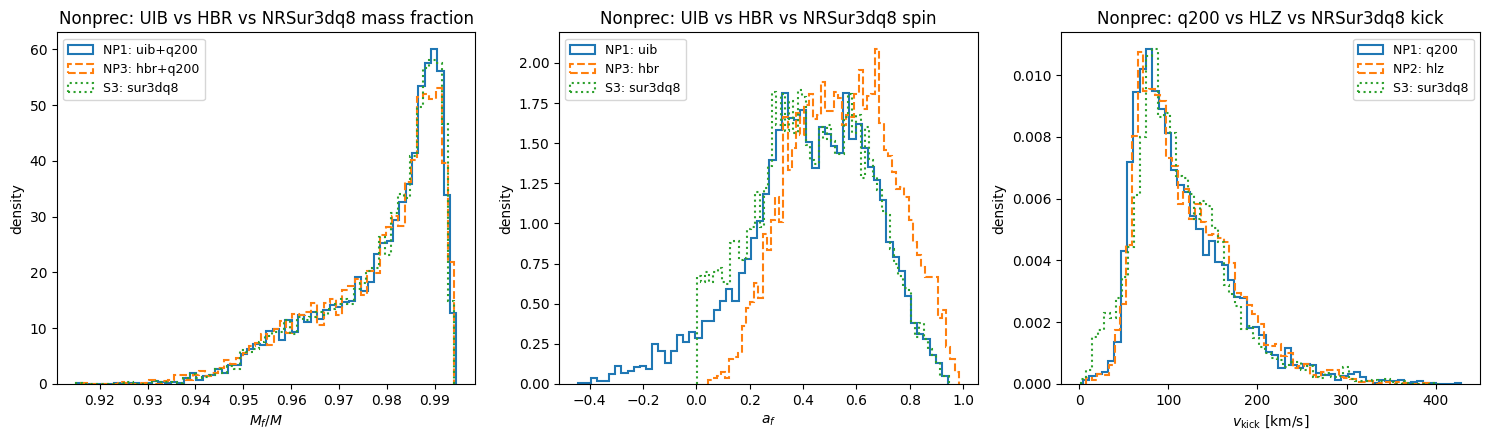

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
kw = dict(bins=60, histtype='step', lw=1.5, density=True)

ax = axes[0]
ax.hist(NP1.Mf / bbh.M, label='NP1: uib+q200', **kw)
ax.hist(NP3.Mf / bbh.M, label='NP3: hbr+q200', ls='--', **kw)
ax.hist(S3.Mf / bbh.M, label='S3: sur3dq8', ls=':', **kw)
ax.set_xlabel('$M_f / M$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Nonprec: UIB vs HBR vs NRSur3dq8 mass fraction')

ax = axes[1]
ax.hist(NP1.af, label='NP1: uib', **kw)
ax.hist(NP3.af, label='NP3: hbr', ls='--', **kw)
ax.hist(S3.af, label='S3: sur3dq8', ls=':', **kw)
ax.set_xlabel('$a_f$')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Nonprec: UIB vs HBR vs NRSur3dq8 spin')

ax = axes[2]
ax.hist(NP1.vkick, label='NP1: q200', **kw)
ax.hist(NP2.vkick, label='NP2: hlz', ls='--', **kw)
ax.hist(S3.vkick, label='S3: sur3dq8', ls=':', **kw)
ax.set_xlabel('$v_{\\rm kick}$ [km/s]')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Nonprec: q200 vs HLZ vs NRSur3dq8 kick')

fig.tight_layout()
plt.show()

## Precessing vs nonprecessing scatter comparison

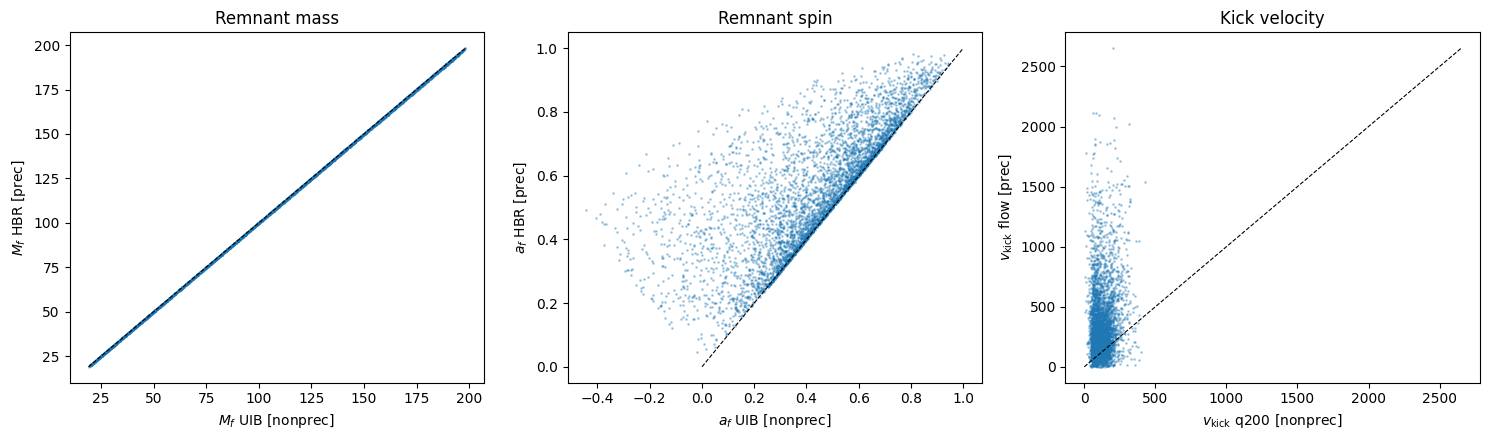

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(NP1.Mf, P1.Mf, s=1, alpha=0.3)
lims = [min(NP1.Mf.min(), P1.Mf.min()), max(NP1.Mf.max(), P1.Mf.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$M_f$ UIB [nonprec]')
ax.set_ylabel('$M_f$ HBR [prec]')
ax.set_title('Remnant mass')

ax = axes[1]
ax.scatter(NP1.af, P1.af, s=1, alpha=0.3)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('$a_f$ UIB [nonprec]')
ax.set_ylabel('$a_f$ HBR [prec]')
ax.set_title('Remnant spin')

ax = axes[2]
ax.scatter(NP1.vkick, P1.vkick, s=1, alpha=0.3)
lims = [0, max(NP1.vkick.max(), P1.vkick.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$v_{\\rm kick}$ q200 [nonprec]')
ax.set_ylabel('$v_{\\rm kick}$ flow [prec]')
ax.set_title('Kick velocity')

fig.tight_layout()
plt.show()

## Nonprecessing kick: q200 vs HLZ scatter

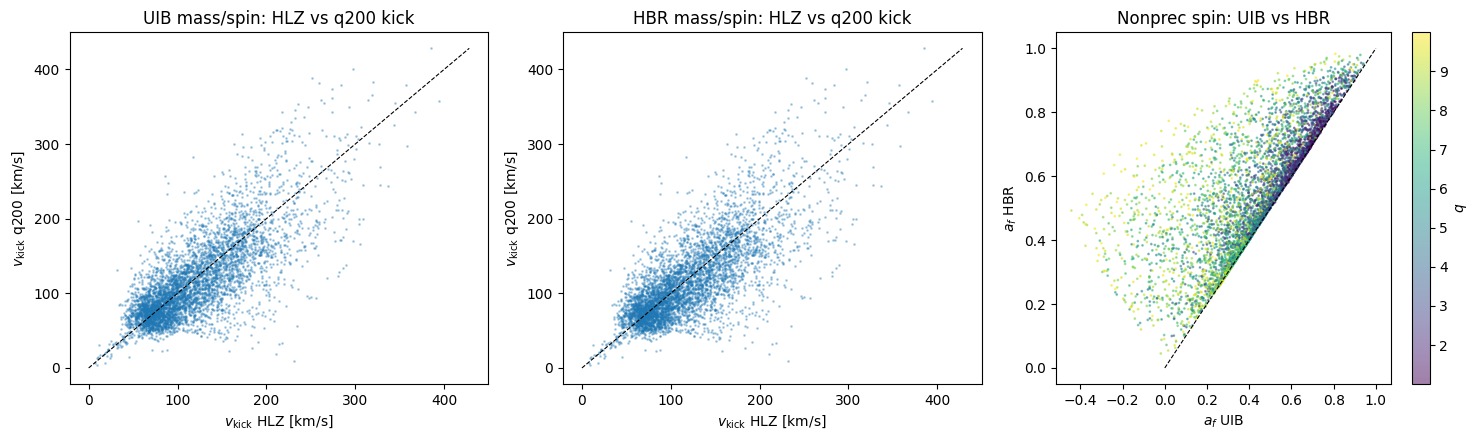

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(NP2.vkick, NP1.vkick, s=1, alpha=0.3)
lims = [0, max(NP1.vkick.max(), NP2.vkick.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$v_{\\rm kick}$ HLZ [km/s]')
ax.set_ylabel('$v_{\\rm kick}$ q200 [km/s]')
ax.set_title('UIB mass/spin: HLZ vs q200 kick')

ax = axes[1]
ax.scatter(NP4.vkick, NP3.vkick, s=1, alpha=0.3)
lims = [0, max(NP3.vkick.max(), NP4.vkick.max())]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlabel('$v_{\\rm kick}$ HLZ [km/s]')
ax.set_ylabel('$v_{\\rm kick}$ q200 [km/s]')
ax.set_title('HBR mass/spin: HLZ vs q200 kick')

ax = axes[2]
sc = ax.scatter(NP1.af, NP3.af, c=bbh.q, s=1, alpha=0.5, cmap='viridis')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('$a_f$ UIB')
ax.set_ylabel('$a_f$ HBR')
ax.set_title('Nonprec spin: UIB vs HBR')
plt.colorbar(sc, ax=ax, label='$q$')

fig.tight_layout()
plt.show()

## Remnant properties vs binary parameters (precessing default)

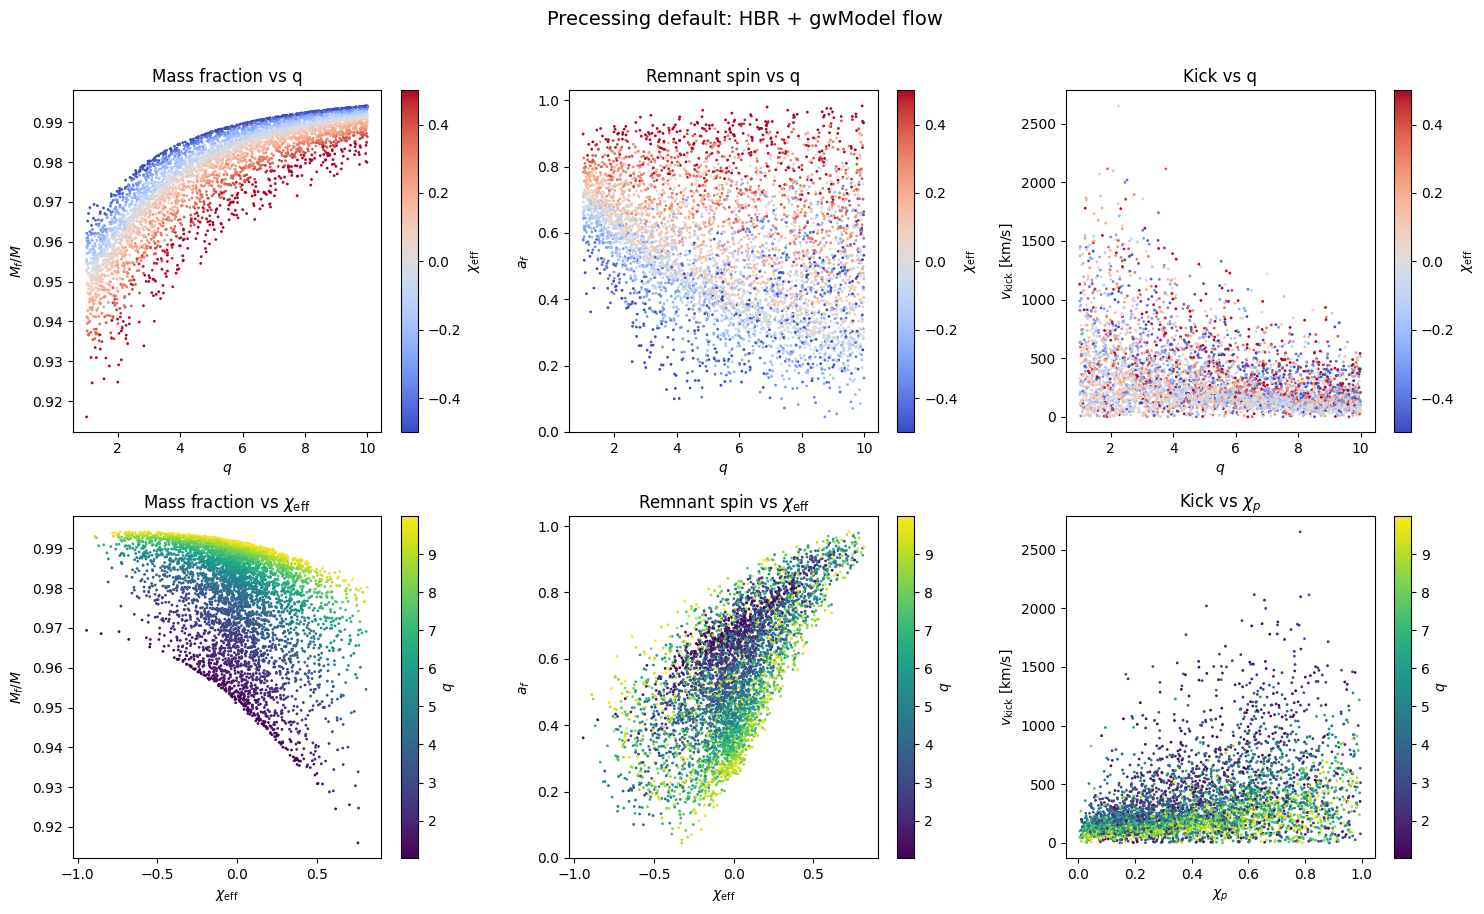

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

ax = axes[0, 0]
sc = ax.scatter(bbh.q, P1.Mf / bbh.M, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$M_f / M$')
ax.set_title('Mass fraction vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[0, 1]
sc = ax.scatter(bbh.q, P1.af, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$a_f$')
ax.set_title('Remnant spin vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[0, 2]
sc = ax.scatter(bbh.q, P1.vkick, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$v_{\\rm kick}$ [km/s]')
ax.set_title('Kick vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[1, 0]
sc = ax.scatter(bbh.chi_eff, P1.Mf / bbh.M, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_{\\rm eff}$')
ax.set_ylabel('$M_f / M$')
ax.set_title('Mass fraction vs $\\chi_{\\rm eff}$')
plt.colorbar(sc, ax=ax, label='$q$')

ax = axes[1, 1]
sc = ax.scatter(bbh.chi_eff, P1.af, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_{\\rm eff}$')
ax.set_ylabel('$a_f$')
ax.set_title('Remnant spin vs $\\chi_{\\rm eff}$')
plt.colorbar(sc, ax=ax, label='$q$')

ax = axes[1, 2]
sc = ax.scatter(bbh.chi_p, P1.vkick, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_p$')
ax.set_ylabel('$v_{\\rm kick}$ [km/s]')
ax.set_title('Kick vs $\\chi_p$')
plt.colorbar(sc, ax=ax, label='$q$')

fig.suptitle('Precessing default: HBR + gwModel flow', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Remnant properties vs binary parameters (nonprecessing default)

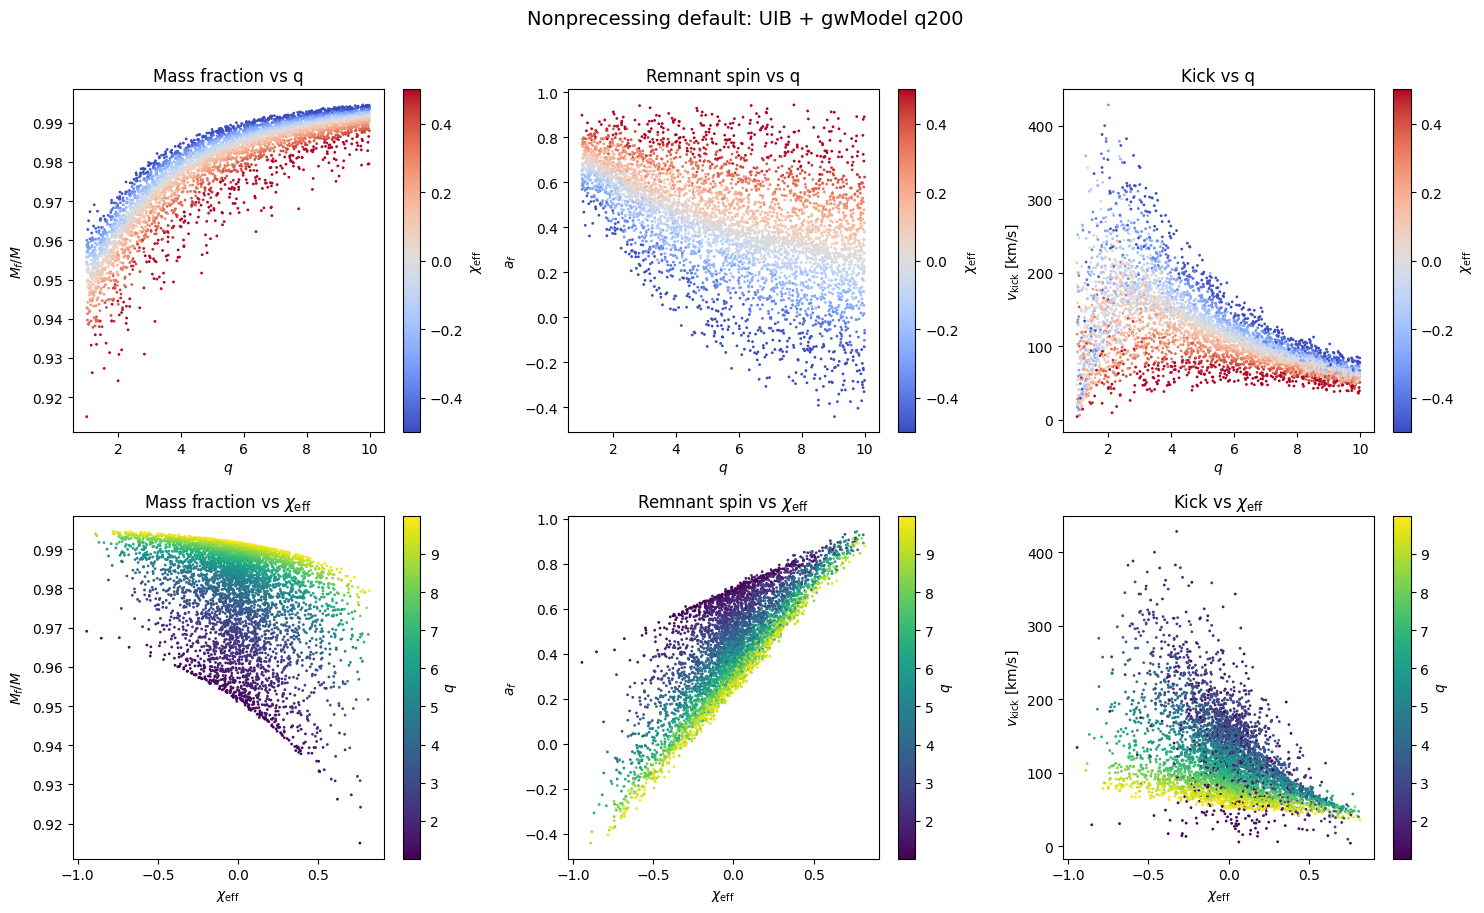

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

ax = axes[0, 0]
sc = ax.scatter(bbh.q, NP1.Mf / bbh.M, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$M_f / M$')
ax.set_title('Mass fraction vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[0, 1]
sc = ax.scatter(bbh.q, NP1.af, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$a_f$')
ax.set_title('Remnant spin vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[0, 2]
sc = ax.scatter(bbh.q, NP1.vkick, c=bbh.chi_eff, s=1, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax.set_xlabel('$q$')
ax.set_ylabel('$v_{\\rm kick}$ [km/s]')
ax.set_title('Kick vs q')
plt.colorbar(sc, ax=ax, label='$\\chi_{\\rm eff}$')

ax = axes[1, 0]
sc = ax.scatter(bbh.chi_eff, NP1.Mf / bbh.M, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_{\\rm eff}$')
ax.set_ylabel('$M_f / M$')
ax.set_title('Mass fraction vs $\\chi_{\\rm eff}$')
plt.colorbar(sc, ax=ax, label='$q$')

ax = axes[1, 1]
sc = ax.scatter(bbh.chi_eff, NP1.af, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_{\\rm eff}$')
ax.set_ylabel('$a_f$')
ax.set_title('Remnant spin vs $\\chi_{\\rm eff}$')
plt.colorbar(sc, ax=ax, label='$q$')

ax = axes[1, 2]
sc = ax.scatter(bbh.chi_eff, NP1.vkick, c=bbh.q, s=1, cmap='viridis')
ax.set_xlabel('$\\chi_{\\rm eff}$')
ax.set_ylabel('$v_{\\rm kick}$ [km/s]')
ax.set_title('Kick vs $\\chi_{\\rm eff}$')
plt.colorbar(sc, ax=ax, label='$q$')

fig.suptitle('Nonprecessing default: UIB + gwModel q200', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()